# Проект: Прокат самокатов GoFast

Мы получили доступ из сервиса проката самокатов GoFast к информации о некоторых пользователях из разных городов и их передвижениях. Проведём анализ этих данных и проверим несколько предположений, которые могут способствовать развитию бизнеса.

Для передвижения по городу пользователи сервиса GoFast используют мобильное приложение. Сервисом можно пользоваться:

- без подписки
    - абонентская плата отсутствует;
    - стоимость одной минуты поездки — 8 рублей;
    - стоимость старта (начала поездки) — 50 рублей;
- с подпиской Ultra
   - абонентская плата — 199 рублей в месяц;
   - стоимость одной минуты поездки — 6 рублей;
   - стоимость старта — бесплатно.

## Описание данных


В основных данных есть информация о пользователях, их поездках и подписках.

Пользователи — `users_go.csv`

- user_id - уникальный идентификатор пользователя;
- name - имя пользователя;
- age - возраст;
- city - город;
- subscription_type - тип подписки (free, ultra).

Поездки — `rides_go.csv`

- user_id - уникальный идентификатор пользователя;
- distance - расстояние, которое пользователь проехал в текущей сессии (в метрах);
- duration - продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»;
- date - дата совершения поездки.

Подписки — `subscriptions_go.csv`

- subscription_type - тип подписки;
- minute_price - стоимость одной минуты поездки по данной подписке;
- start_ride_price - стоимость начала поездки;
- subscription_fee - стоимость ежемесячного платежа.

## Импорт библиотек

In [1]:
from IPython.display import clear_output

In [2]:
!pip install seaborn

clear_output()

In [3]:
import os
import pandas as pd
import numpy as np 
import scipy.stats as st 
import seaborn as sns

from scipy.stats import binom, poisson
from scipy.stats import ttest_ind
from matplotlib import pyplot as plt
from math import sqrt

## Загрузка данных

In [5]:
users = pd.read_csv("https://code.s3.yandex.net/datasets/users_go.csv")
rides = pd.read_csv("https://code.s3.yandex.net/datasets/rides_go.csv")
subscriptions = pd.read_csv("https://code.s3.yandex.net/datasets/subscriptions_go.csv")

In [6]:
display(pd.DataFrame(users.head(10)))
users.info()
display(pd.DataFrame(rides.head(10)))
rides.info()
display(pd.DataFrame(subscriptions.head(10)))
subscriptions.info()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


- При поверхностном анализе можно сделать вывод, что данные представлены верно, отсутствуют пропущенные значения. Однако следует учесть, что тип данных в столбце rides[’date’] следует изменить.

## Предобработка данных

In [7]:
rides['date'] = pd.to_datetime(rides['date'])
print(f"Данные за период с {rides['date'].min()} по {rides['date'].max()}")

Данные за период с 2021-01-01 00:00:00 по 2021-12-30 00:00:00


In [8]:
rides['month'] = rides['date'].dt.month

In [9]:
# проверим наличие пропущенных значений и дубликатов в датафреймах
print("Информация о пользователях:")
print()
print("Пропущенные значения:")
print(users.isna().sum().to_string())
print(users.shape)
print()
print("Дубликаты:")
print(users.duplicated().sum())
print()

print("Информация о поездках:")
print()
print("Пропущенные значения:")
print(rides.isna().sum().to_string())
print(rides.shape)
print()
print("Дубликаты:")
print(rides.duplicated().sum())
print()

print("Информация о подписках:")
print()
print("Пропущенные значения:")
print(subscriptions.isna().sum().to_string())
print(subscriptions.shape)
print()
print("Дубликаты:")
print(subscriptions.duplicated().sum())

Информация о пользователях:

Пропущенные значения:
user_id              0
name                 0
age                  0
city                 0
subscription_type    0
(1565, 5)

Дубликаты:
31

Информация о поездках:

Пропущенные значения:
user_id     0
distance    0
duration    0
date        0
month       0
(18068, 5)

Дубликаты:
0

Информация о подписках:

Пропущенные значения:
subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
(2, 4)

Дубликаты:
0


In [10]:
# обработаем присутствующие значения дубликатов
print(len(users['user_id']))
users = users.drop_duplicates().reset_index(drop = True)
print(len(users['user_id']))

1565
1534


Мы изменили тип данных в столбце `date`, на его основе добавили новый столбец с номером месяца - `month`, а так же нашли дубликаты в датафрейме `users`, и избавились от них.

## Исследовательский анализ данных

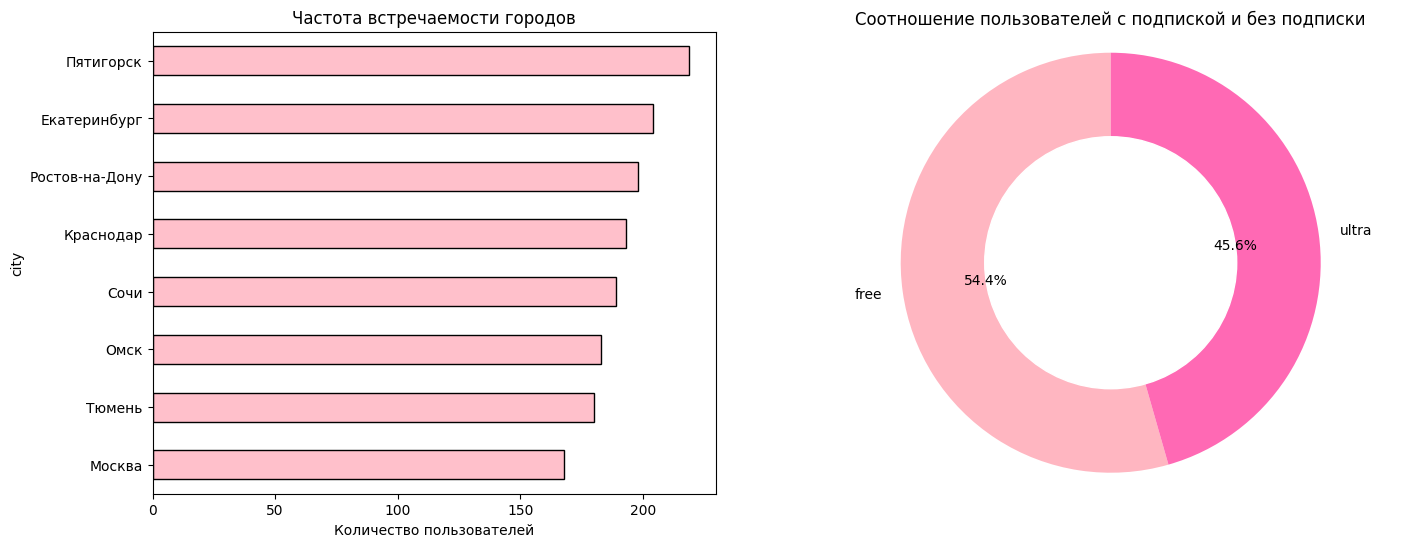

In [11]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

city_counts = users['city'].value_counts().sort_values()
city_counts.plot(kind = 'barh', color = 'pink', edgecolor = 'black', ax = axs[0]) 
axs[0].set_xlabel('Количество пользователей')
axs[0].set_title('Частота встречаемости городов')

sizes = [835, 699]
labels = ['free', 'ultra']
axs[1].pie(sizes, labels = labels, autopct = '%1.1f%%', startangle = 90, colors = ['LightPink', 'HotPink'])
axs[1].axis('equal')
inner_circle = plt.Circle((0, 0), 0.6, color='white')
axs[1].add_artist(inner_circle)
axs[1].set_title('Соотношение пользователей с подпиской и без подписки')

plt.show()

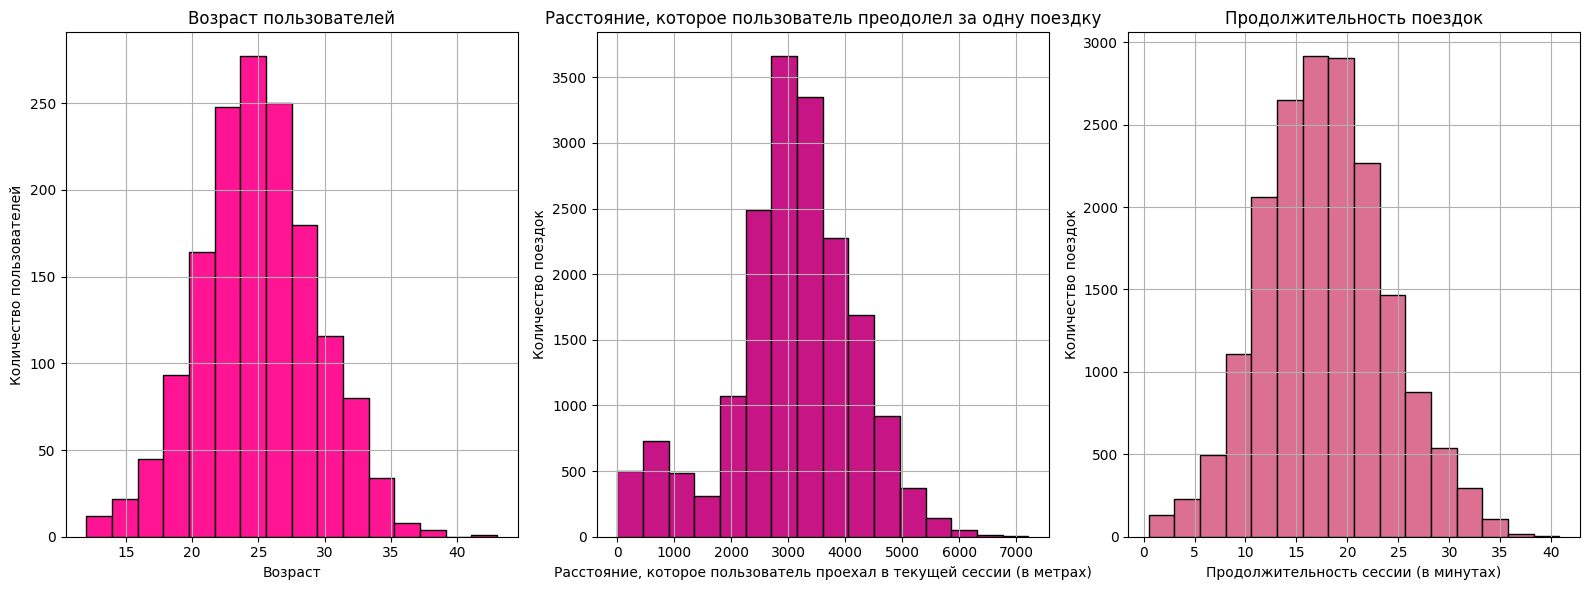

In [12]:
fig, axs = plt.subplots(1, 3, figsize = (16, 6))

users['age'].hist(bins = 16, color = 'DeepPink', edgecolor = 'black', ax = axs[0])
axs[0].set_xlabel('Возраст')
axs[0].set_ylabel('Количество пользователей')
axs[0].set_title('Возраст пользователей')

rides['distance'].hist(bins = 16, color = 'MediumVioletRed', edgecolor = 'black', ax = axs[1])
axs[1].set_xlabel('Расстояние, которое пользователь проехал в текущей сессии (в метрах)')
axs[1].set_ylabel('Количество поездок')
axs[1].set_title('Расстояние, которое пользователь преодолел за одну поездку')

rides['duration'].hist(bins = 16, color = 'PaleVioletRed', edgecolor = 'black', ax = axs[2])
axs[2].set_xlabel('Продолжительность сессии (в минутах)')
axs[2].set_ylabel('Количество поездок')
axs[2].set_title('Продолжительность поездок')

plt.tight_layout()
plt.show()

In [13]:
print(users['age'].describe())
print()
print(rides['distance'].describe())
print()
print(rides['duration'].describe())

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64


In [14]:
ridess = rides[rides['duration'] > 1]

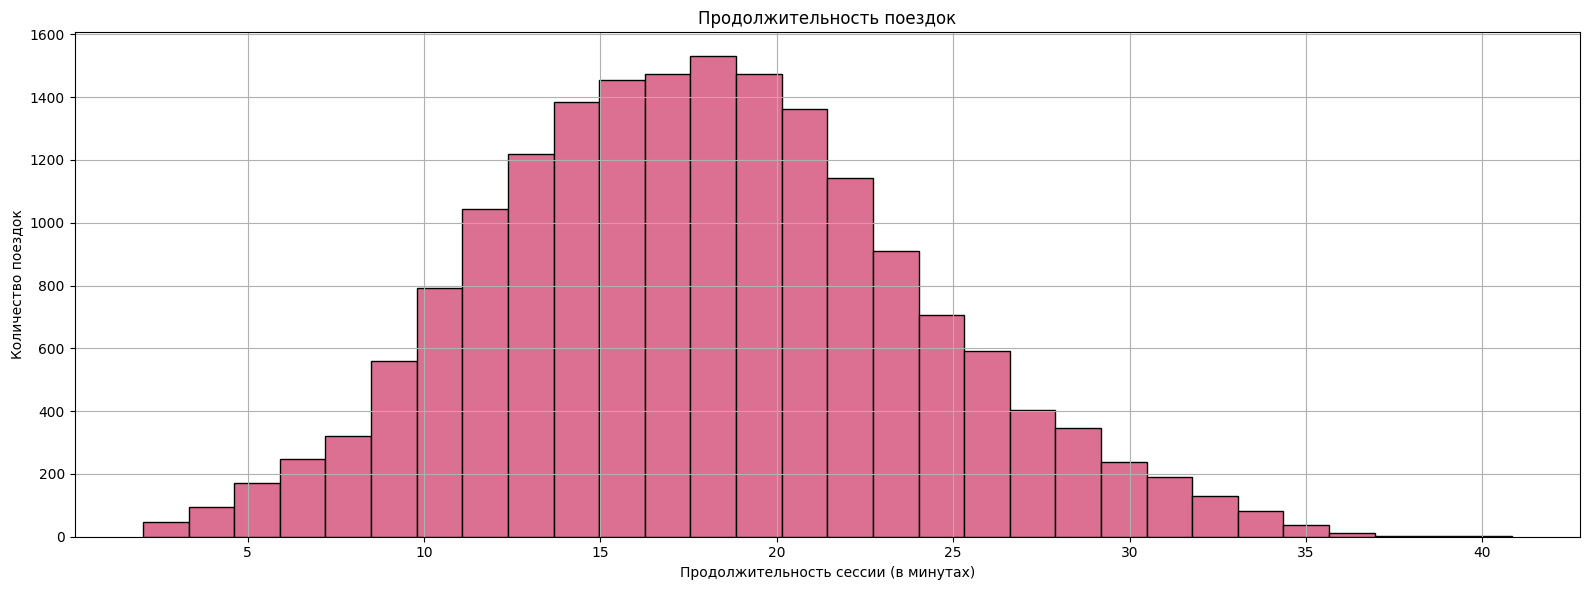

In [15]:
fig, axs = plt.subplots(1, 1, figsize = (16, 6))

ridess['duration'].hist(bins = 30, color = 'palevioletred', edgecolor = 'black', ax = axs)  
axs.set_xlabel('Продолжительность сессии (в минутах)')
axs.set_ylabel('Количество поездок')
axs.set_title('Продолжительность поездок')

plt.tight_layout()
plt.show()

- Больше всего пользователей зарегистрировано в Пятигорске, а меньше всего — в Москве. Доля пользователей с подпиской составляет 45,6 %, а без подписки — 54,4 %. Средний возраст пользователей — 25 лет. Расстояние, которое пользователи преодолевают за одну поездку, составляет примерно 3 километра, а продолжительность поездок — около 18 минут.

- На графике видны пики в показателях расстояния поездок. Это может быть связано с повышенным спросом в определённые периоды времени. Возможные причины такого спроса включают начало и конец рабочего дня, учёбы или сезона, а также изменение расписания общественного транспорта и активности в различных сферах деятельности.

## Объединение данных

In [16]:
print('Длина до объединения:', len(rides['user_id']))
merged_data = users.merge(rides, on = 'user_id', how = 'left')
merged_data = merged_data.merge(subscriptions, on = 'subscription_type', how = 'left')
print('Длина после объединения:', len(merged_data['user_id']))
print()
print('Пропуски в столбцах:')
print(merged_data.isna().sum())
print()
merged_data.head()

Длина до объединения: 18068
Длина после объединения: 18068

Пропуски в столбцах:
user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64



,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


In [17]:
free = merged_data[merged_data['subscription_type'] == 'free'].copy()
ultra = merged_data[merged_data['subscription_type'] == 'ultra'].copy()

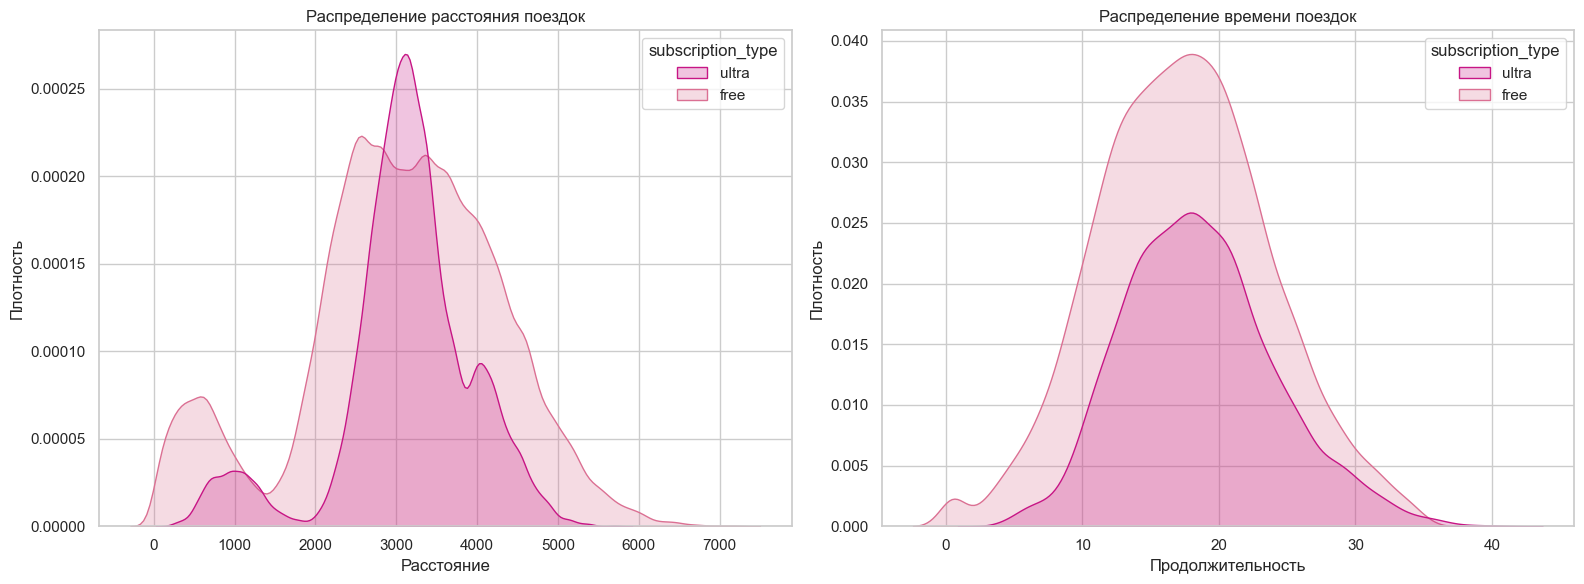

In [18]:
sns.set_theme(style = "whitegrid")

fig, axs = plt.subplots(1, 2, figsize = (16, 6))

sns.kdeplot(data = merged_data, x = 'distance', hue = 'subscription_type', fill = True, palette = ['MediumVioletRed', 'PaleVioletRed'], ax = axs[0], bw_adjust=0.5)
axs[0].set_title('Распределение расстояния поездок')
axs[0].set_xlabel('Расстояние')
axs[0].set_ylabel('Плотность')

sns.kdeplot(data = merged_data, x = 'duration', hue = 'subscription_type', fill = True, palette = ['MediumVioletRed', 'PaleVioletRed'], ax = axs[1])
axs[1].set_title('Распределение времени поездок')
axs[1].set_xlabel('Продолжительность')
axs[1].set_ylabel('Плотность')

plt.tight_layout()
plt.show()

Различия в распределении расстояния и времени поездок между пользователями с подпиской и без неё незначительны, за исключением того, что пользователи с подпиской в среднем преодолевают несколько большее расстояние.

## Подсчёт выручки

In [19]:
merged_data['distance'] = merged_data['distance'].round().astype(int)


In [20]:
aggregated_data = merged_data.groupby(['user_id', 'month']).agg({'distance':'sum', 'duration':['sum', 'count'],
'subscription_type':'first','minute_price':'first','start_ride_price':'first','subscription_fee':'first'})

aggregated_data.columns = ['sum_distance', 'sum_duration', 'count_rides','subscription_type', 'minute_price',
'start_ride_price', 'subscription_fee']
aggregated_data.reset_index(inplace = True)

display(aggregated_data.head())
print(aggregated_data.shape[0])

aggregated_data['monthly_revenue'] = aggregated_data['start_ride_price'] * aggregated_data['count_rides'] + \
aggregated_data['minute_price'] * aggregated_data['sum_duration'] + aggregated_data['subscription_fee']
display(aggregated_data.head())
print(aggregated_data.shape[0])

,user_id,month,sum_distance,sum_duration,count_rides,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,1,7028,41.416640,2,ultra,6,0,199
1,1,4,754,6.232113,1,ultra,6,0,199
2,1,8,6724,44.776802,2,ultra,6,0,199
3,1,10,5810,31.578017,2,ultra,6,0,199
4,1,11,7004,53.397424,3,ultra,6,0,199


11331


,user_id,month,sum_distance,sum_duration,count_rides,subscription_type,minute_price,start_ride_price,subscription_fee,monthly_revenue
0,1,1,7028,41.416640,2,ultra,6,0,199,447.499843
1,1,4,754,6.232113,1,ultra,6,0,199,236.392681
2,1,8,6724,44.776802,2,ultra,6,0,199,467.660815
3,1,10,5810,31.578017,2,ultra,6,0,199,388.468102
4,1,11,7004,53.397424,3,ultra,6,0,199,519.384541


11331


## Проверка гипотез

### Вопрос №1

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверим гипотезу. Используем исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

`Нулевая гипотеза`  предполагает, что пользователи с подпиской тратят такое же количество времени на поездки, как и пользователи без подписки.

`Альтернативная гипотеза` в данном случае будет звучать следующим образом: Среднее время поездок у пользователей с подпиской больше, чем у пользователей без подписки.

### Ответ 

In [21]:
subscriber = merged_data[merged_data['subscription_type'] == 'ultra']['duration']
nonsubscriber = merged_data[merged_data['subscription_type'] == 'free']['duration']

t_stat, p_val_ttest = st.ttest_ind(subscriber, nonsubscriber, equal_var = True, alternative = 'greater')

print(f'Результат t-теста: t_stat = {t_stat}, p_val_ttest = {p_val_ttest}')

if p_val_ttest < 0.05:
    print("Отвергаем нулевую гипотезу. Пользователи с подпиской тратят больше времени на поездки.")
else:
    print("Не отвергаем нулевую гипотезу. Нет статистически значимого различия во времени поездки пользователей с подпиской и без подписки.")

Результат t-теста: t_stat = 12.241203729044017, p_val_ttest = 1.2804098316645613e-34
Отвергаем нулевую гипотезу. Пользователи с подпиской тратят больше времени на поездки.


### Вопрос №2

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?

`Нулевая гипотеза` предполагает, что среднее расстояние, преодолеваемое пользователями с подпиской, не больше 3130 метров.

`Альтернативная` — что пользователи с подпиской проезжают больше 3130 метров.

### Ответ 

In [22]:
subscriber = merged_data[merged_data['subscription_type'] == 'ultra']

t_stat, p_val = st.ttest_1samp(subscriber['distance'], 3130, alternative = 'greater')

print(f'Результат t-теста: t_stat = {t_stat}, p_val_ttest = {p_val_ttest}')

if p_val < 0.05:
    print("Отвергаем нулевую гипотезу. Среднее расстояние превышает 3130 метров.")
else:
    print("Не отвергаем нулевую гипотезу. Среднее расстояние не превышает 3130 метров.")

Результат t-теста: t_stat = -1.4023114642535002, p_val_ttest = 1.2804098316645613e-34
Не отвергаем нулевую гипотезу. Среднее расстояние не превышает 3130 метров.


### Вопрос №3

Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. Сделайте вывод.

`Нулевая гипотеза` - помесячная выручка от пользователей с подпиской по месяцам будет такая же, как и выручка от пользователей без подписки.

`Альтернативная` - помесячная выручка от пользователей с подпиской по месяцам будет выше выручки пользователей без подписки.

### Ответ 

In [23]:
free_revenue = aggregated_data[aggregated_data['subscription_type'] == 'free']['monthly_revenue']
ultra_revenue = aggregated_data[aggregated_data['subscription_type'] == 'ultra']['monthly_revenue']

t_stat, p_val = st.ttest_ind(ultra_revenue, free_revenue, alternative = 'greater') 

print(f'Результат t-теста: t_stat = {t_stat}, p_val_ttest = {p_val_ttest}')

if p_val_ttest < 0.05:  
    print("Отвергаем нулевую гипотезу. Средняя помесячная выручка от пользователей с подпиской выше.")
else:
    print("Не отвергаем нулевую гипотезу. Средняя помесячная выручка от пользователей с подпиской не отличается от выручки от пользователей без подписки.")

Результат t-теста: t_stat = 12.74714774216835, p_val_ttest = 1.2804098316645613e-34
Отвергаем нулевую гипотезу. Средняя помесячная выручка от пользователей с подпиской выше.


В ходе анализа гипотез мы обнаружили, что компании выгодно привлекать пользователей с подпиской. Это обусловлено тем, что такие пользователи <u>тратят больше времени на поездки,</u> что позволяет им совершать больше поездок и увеличивает прибыль. Кроме того, среднее <u>расстояние, которое они преодолевают за одну поездку, составляет менее 3130 метров,</u> что предотвращает износ самоката. Наконец, <u>средняя выручка от пользователей с подпиской выше,</u> что подтверждает экономическую эффективность такого подхода.

### Вопрос №4

Представим такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест нам понадобился бы для проверки этой гипотезы?

### Ответ 

Подходящим методом будет **`scipy.stats.ttest_rel`** - <u>t-тест для связанных выборок</u>. Этот тест позволит сравнить среднее число обращений до и после обновления для каждого пользователя и оценить статистическую значимость различий между ними. Если уровень значимости (например, 0,05) будет превышен, можно сделать вывод о значительном уменьшении количества обращений после обновления серверов.

## Распределения

Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 
Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Выясним, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберем параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируем ответ на вопрос о количестве промокодов.

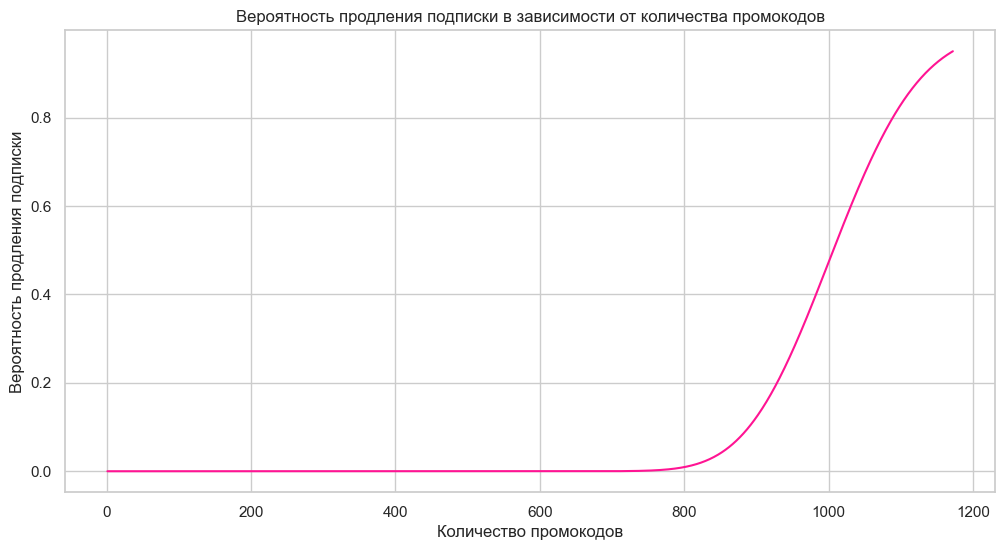

Минимальное количество промокодов, которое нужно разослать: 1172


In [24]:
# параметры задачи
p_success = 0.1  # вероятность продления подписки
n_clients = 100  # минимальное количество клиентов, которые должны продлить подписку
p_fail = 0.05  # вероятность не выполнить план

# найдем минимальное количество промокодов
n_promocodes = 1
while binom.cdf(n_clients, n_promocodes, p_success) > p_fail:
    n_promocodes += 1

# построим график вероятностей продления подписки
x = np.arange(1, n_promocodes+1)
y = [1 - binom.cdf(n_clients, n, p_success) for n in x]

plt.figure(figsize = (12, 6)) 
plt.plot(x, y, color = 'DeepPink')
plt.xlabel('Количество промокодов')
plt.ylabel('Вероятность продления подписки')
plt.title('Вероятность продления подписки в зависимости от количества промокодов')
plt.grid(True)
plt.show()

print(f"Минимальное количество промокодов, которое нужно разослать: {n_promocodes}")

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации построим примерный график распределения и оценим вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

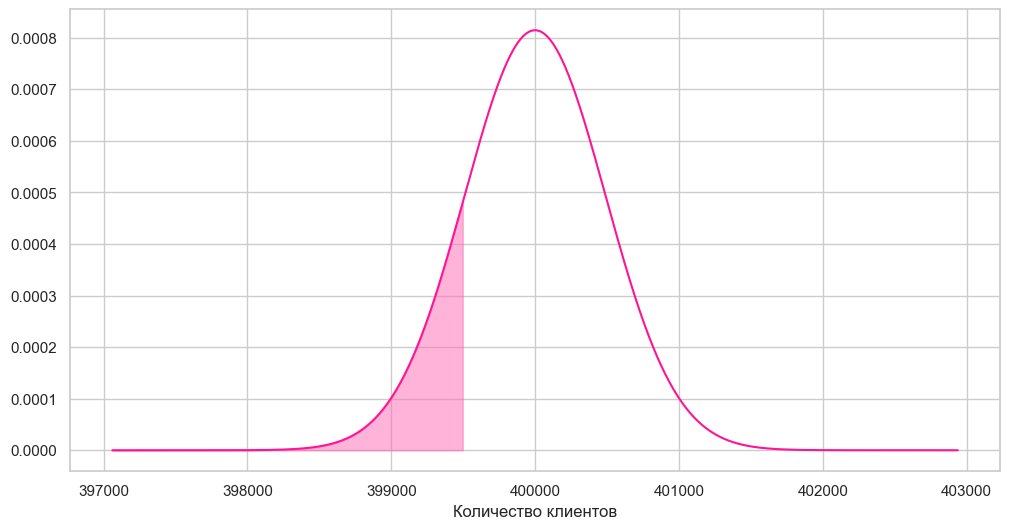

Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей: 15.37%


In [25]:
# параметры задачи
p_open = 0.4  # вероятность открытия уведомления
n_clients = 1000000  # количество клиентов, которым отправляется уведомление

mu = n_clients * p_open
sigma = np.sqrt(n_clients * p_open * (1 - p_open))

x = np.linspace(mu - 6*sigma, mu + 6*sigma, 1000) 
y = st.norm.pdf(x, mu, sigma)

plt.figure(figsize = (12, 6))  
plt.plot(x, y, color = 'DeepPink')
plt.fill_between(x, y, where = (x < 399500), color = 'HotPink', alpha = 0.5)
plt.xlabel('Количество клиентов')
plt.show()

# оценка вероятности открытия не более 399,5 тыс. пользователей
probability = st.norm.cdf(399500, mu, sigma) * 100
print(f"Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей: {probability:.2f}%")

## Общий вывод

*В ходе работы были выполнены следующие действия:*

1. Преобразован столбец date в тип данных даты pandas, добавлен новый столбец с номером месяца на основе столбца date и проведена проверка наличия пропущенных значений и дубликатов в датафреймах.

2. Обработаны присутствующие значения дубликатов, проведено описание и визуализация общей информации о пользователях и поездках: частоту встречаемости городов <u>(наибольшее количество пользователей зарегистрировано в городе Пятигорск, а наименьшее — в Москве),</u> соотношение пользователей с подпиской и без подписки <u>(пользователей с подпиской составляет 45,6 %, а без подписки — 54,6 %),</u> возраст пользователей <u>(в среднем 25 лет),</u> расстояние, которое пользователь преодолел за одну поездку <u>(примерно 3 км),</u> продолжительность поездок <u>(около 20 минут).</u>

3. Данные о пользователях, поездках и подписках были объединены в один датафрейм с использованием, а также созданы два датафрейма с данными о пользователях с подпиской и без.

4. Информация о расстоянии и времени поездок для пользователей с подпиской и без была визуализирована по распределению расстояния и времени поездок, создан датафрейм с агрегированными данными о поездках, добавлен столбец с помесячной выручкой от каждого пользователя.

5. Была проверена гипотеза о том, тратят ли пользователи с подпиской больше времени на поездки, и было выяснено, что есть статистически значимая разницы между временем поездок пользователей с подпиской и без.

6. Также было установлено, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров, и что помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки.

На основе проведённого анализа были сделаны следующие выводы: для выполнения плана продления подписки <u>необходимо отправить 1172 промокода 100 текущим клиентам.</u> Вероятность невыполнения плана составляет 5%. График распределения показывает, что <u>при отправке 1 миллиона уведомлений только 399,5 тысяч пользователей откроют их с вероятностью 15,37%.</u>

В связи с этим компании рекомендуется:
- Определить наиболее результативные каналы взаимодействия с клиентами.
- Использовать сегментацию аудитории для отправки релевантных предложений и акций.
- Автоматизировать процессы рассылки для оптимизации временных и ресурсных затрат.
- Регулярно анализировать результаты рассылок и корректировать стратегию на основе полученных данных.